In [15]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
import os
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [16]:
train_dir = r"C:\Suren\Academmics\6th sem\AI & EDGE COMPUTING\Lab\Data Sets\Week 12-15\Forest fire\Train_Data"
test_dir = r"C:\Suren\Academmics\6th sem\AI & EDGE COMPUTING\Lab\Data Sets\Week 12-15\Forest fire\Test_Data"

In [17]:
train = ImageDataGenerator(rescale=1/255)
test = ImageDataGenerator(rescale=1/255)

test_dataset = test.flow_from_directory(
    r"C:\Suren\Academmics\6th sem\AI & EDGE COMPUTING\Lab\Data Sets\Week 12-15\forest_fire\Testing",
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary')
train_dataset = train.flow_from_directory(
    r"C:\Suren\Academmics\6th sem\AI & EDGE COMPUTING\Lab\Data Sets\Week 12-15\forest_fire\Training and Validation",
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary')

Found 68 images belonging to 2 classes.
Found 1832 images belonging to 2 classes.


In [18]:
test_dataset.class_indices

{'fire': 0, 'nofire': 1}

In [23]:
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(keras.layers.MaxPool2D(2, 2))
model.add(keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(keras.layers.MaxPool2D(2, 2))
model.add(keras.layers.Conv2D(128, (3, 3), activation='relu'))
model.add(keras.layers.MaxPool2D(2, 2))
model.add(keras.layers.Conv2D(128, (3, 3), activation='relu'))
model.add(keras.layers.MaxPool2D(2, 2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

C:\Users\SUREN KARTHIK.BJ\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
r = model.fit(train_dataset, epochs=10, validation_data=test_dataset)

C:\Users\SUREN KARTHIK.BJ\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 47s 716ms/step - accuracy: 0.7762 - loss: 0.4534 - val_accuracy: 0.8676 - val_loss: 0.2897
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 28s 480ms/step - accuracy: 0.9234 - loss: 0.2087 - val_accuracy: 0.8824 - val_loss: 0.3046
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 29s 490ms/step - accuracy: 0.9475 - loss: 0.1924 - val_accuracy: 0.8529 - val_loss: 0.3573
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 29s 497ms/step - accuracy: 0.9559 - loss: 0.1327 - val_accuracy: 0.8088 - val_loss: 0.4058
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 453ms/step - accuracy: 0.9636 - loss: 0.1095 - val_accuracy: 0.9265 - val_loss: 0.1877
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 449ms/step - accuracy: 0.9668 - loss: 0.1026 - val_accuracy: 0.8088 - val_loss: 0.4339
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 27s 471ms/step - accuracy: 0.9755 - loss: 0.0849 - val_accuracy: 0.9118 - val_loss: 0.1710
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 27s 464ms/step - accuracy: 0.9756 - loss: 0.0744 - val_accu

In [27]:
predictions = model.predict(test_dataset)
predictions = np.round(predictions)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step


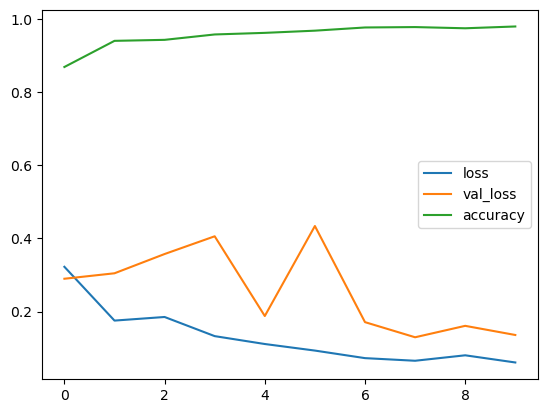

In [29]:
import matplotlib.pyplot as plt

plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.plot(r.history['accuracy'], label='accuracy')
plt.legend()

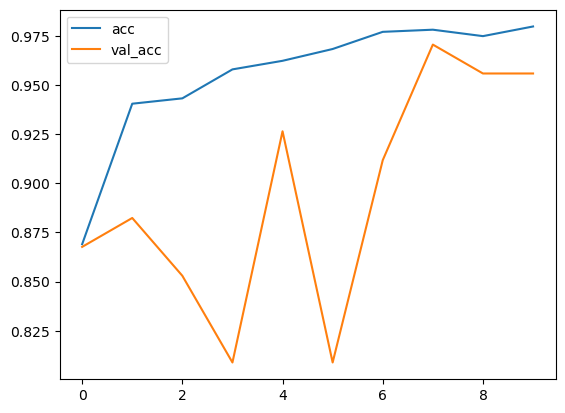

In [31]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

plt.show()

In [33]:
def predictImage(filename):
    img1 = image.load_img(filename, target_size=(150, 150))
    plt.imshow(img1)
    Y = image.img_to_array(img1)
    X = np.expand_dims(Y, axis=0)
    val = model.predict(X)
    print(val)
    if val == 1:
        plt.xlabel("No Fire", fontsize=25)
    elif val == 0:
        plt.xlabel("Fire", fontsize=25)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
[[1.]]


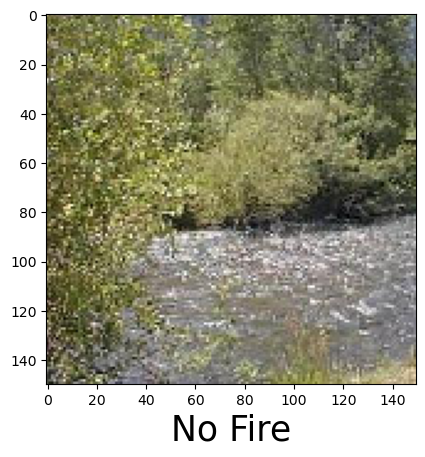

In [35]:
predictImage(r"C:\Suren\Academmics\6th sem\AI & EDGE COMPUTING\Lab\Data Sets\Week 12-15\forest_fire\Training and Validation\nofire\abc202.jpg")